In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import shutil

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

# STEP 1: Imported Required Libraries

### Explanation:
In this step, we import all the necessary libraries required for the project.

- **os** → used to handle file paths and directories  
- **shutil** → used to copy and move files  
- **numpy** → used for numerical operations and handling image arrays  
- **matplotlib** → used to plot graphs (like accuracy and loss)  
- **tensorflow** → main deep learning framework  

### Keras Modules:
- **ImageDataGenerator** → loads and preprocesses images  
- **MobileNetV2** → pretrained model for transfer learning  
- **layers, models** → used to build custom neural networks  

**Purpose:** To set up all tools required for data processing and model building.

---

In [6]:
original_train_dir = "/kaggle/input/datasets/biaiscience/dogs-vs-cats/train/train"

# STEP 2: Defined Dataset Path

### Explanation:
Here, we define the path of the original dataset where all images are stored.

- **original_train_dir** → location of training images  

**Purpose:** To tell the program where the dataset is located.

---

In [10]:
base_dir = "/kaggle/working/data"

train_dir = os.path.join(base_dir, "train")
cat_dir = os.path.join(train_dir, "cat")
dog_dir = os.path.join(train_dir, "dog")

os.makedirs(cat_dir, exist_ok=True)
os.makedirs(dog_dir, exist_ok=True)

# STEP 3: Created Proper Directory Structure

### Explanation:
Deep learning models using `flow_from_directory()` require images to be organized into **class-wise folders**.

### Required Structure:

- **os.makedirs()** → creates folders if they do not already exist  

**Purpose:** To organize the dataset in a format that the model can understand.  
**Reason:** Each folder represents a class (cat or dog).

---

In [13]:
for filename in os.listdir(original_train_dir):
    src = os.path.join(original_train_dir, filename)
    
    if filename.startswith("cat"):
        dst = os.path.join(cat_dir, filename)
        shutil.copy(src, dst)
        
    elif filename.startswith("dog"):
        dst = os.path.join(dog_dir, filename)
        shutil.copy(src, dst)

# STEP 4: Organized Images into Class Folders

### Explanation:
The original dataset contains images in a single folder with names like:
- `cat.1.jpg`
- `dog.2.jpg`

This step:
- Reads each file name  
- Checks whether it belongs to a cat or dog  
- Copies it into the correct folder (`cat/` or `dog/`)  

### Functions Used:
- **os.listdir()** → lists all files in a directory  
- **shutil.copy()** → copies files to another location  

**Purpose:** To separate images into their respective classes.  
**Result:** The model can automatically assign labels.

---

In [14]:
print(os.listdir(train_dir))

['dog', 'cat']


# STEP 5: Verified Folder Structure

### Explanation:
This step checks whether the folders were created correctly.

- **os.listdir(train_dir)** → displays all subfolders  

**Purpose:** To confirm that the dataset is correctly structured before training.

---


In [15]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

# STEP 6: Data Preprocessing and Augmentation

### Explanation:
In this step, we prepare the images for training.

### Key Operations:

- **rescale=1./255**  
  → Converts pixel values from 0–255 to 0–1  
  → Helps in stable and faster training  

- **rotation_range=20**  
  → Randomly rotates images  

- **zoom_range=0.2**  
  → Random zoom in/out  

- **horizontal_flip=True**  
  → Flips images horizontally  

- **validation_split=0.2**  
  → Uses 20% of data for validation  

**Purpose:**  
- Improve model performance  
- Reduce overfitting  
- Make the model more robust to real-world variations  

---

In [16]:
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.


# STEP 7: Loaded Data Using flow_from_directory

### Explanation:
This step loads images from folders and prepares them for training.

### Key Parameters:

- **target_size=(224,224)**  
  → Resizes all images to a fixed size  

- **batch_size=32**  
  → Processes 32 images at a time  

- **class_mode='binary'**  
  → Used for two classes (cat vs dog)  

- **subset='training' / 'validation'**  
  → Splits data into training and validation sets  

**Purpose:**  
To convert images into batches and assign labels automatically.

---

In [17]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

I0000 00:00:1776346026.092963      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776346026.098916      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# STEP 8: Built Model Using Transfer Learning

### Explanation:
Instead of training a model from scratch, we use a pretrained model.

- **MobileNetV2** is trained on a large dataset (ImageNet)

### Key Points:

- **include_top=False**  
  → Removes original classification layer  

- **base_model.trainable = False**  
  → Freezes pretrained layers  

### Custom Layers Added:

- **GlobalAveragePooling2D()** → converts features into a vector  
- **Dense(128, activation='relu')** → learning layer  
- **Dropout(0.5)** → prevents overfitting  
- **Dense(1, activation='sigmoid')** → final output layer  

**Purpose:**  
- Faster training  
- Better accuracy  
- Less data required  

---

In [18]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# STEP 9: Compiled the Model

### Explanation:
This step defines how the model will learn.

- **optimizer='adam'** → updates weights efficiently  
- **loss='binary_crossentropy'** → suitable for binary classification  
- **metrics=['accuracy']** → measures performance  

**Purpose:**  
To configure the model for training.

---

In [19]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1776346058.781189     178 service.cc:152] XLA service 0x7d0344011cf0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776346058.781224     178 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1776346058.781228     178 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1776346059.899251     178 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-16 13:27:49.004398: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-16 13:27:49.141114: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1776346071.226128     178 device_co

625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step - accuracy: 0.9479 - loss: 0.1286

2026-04-16 13:32:21.283343: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-16 13:32:21.419738: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


625/625 ━━━━━━━━━━━━━━━━━━━━ 290s 435ms/step - accuracy: 0.9479 - loss: 0.1286 - val_accuracy: 0.9752 - val_loss: 0.0662
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 258s 412ms/step - accuracy: 0.9694 - loss: 0.0761 - val_accuracy: 0.9772 - val_loss: 0.0553
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 255s 408ms/step - accuracy: 0.9770 - loss: 0.0592 - val_accuracy: 0.9758 - val_loss: 0.0590
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 255s 408ms/step - accuracy: 0.9755 - loss: 0.0602 - val_accuracy: 0.9788 - val_loss: 0.0547
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 254s 407ms/step - accuracy: 0.9796 - loss: 0.0546 - val_accuracy: 0.9776 - val_loss: 0.0549
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 255s 408ms/step - accuracy: 0.9786 - loss: 0.0575 - val_accuracy: 0.9814 - val_loss: 0.0538
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 253s 406ms/step - accuracy: 0.9776 - loss: 0.0556 - val_accuracy: 0.9798 - val_loss: 0.0552
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 254s 406ms/step - accuracy: 0.9790 - loss: 0.05

# STEP 10: Trained the Model

### Explanation:
The model learns patterns from the training data.

- **epochs=10** → number of times the model sees the entire dataset  
- **validation_data** → used to check performance during training  

**Purpose:**  
To train the model to distinguish between cats and dogs.

---

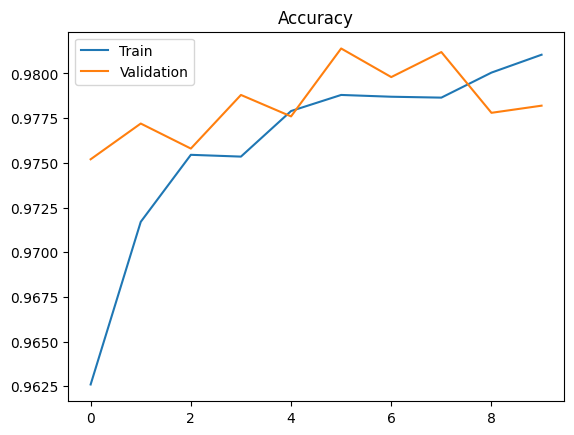

In [20]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

# STEP 11: Ploted Accuracy Graph

### Explanation:
This step visualizes model performance.

- Training accuracy vs Validation accuracy  

**Purpose:**  
- To check if the model is learning properly  
- To detect overfitting

---



In [21]:
val_loss, val_acc = model.evaluate(val_data)
print("Validation Accuracy:", val_acc)

157/157 ━━━━━━━━━━━━━━━━━━━━ 52s 332ms/step - accuracy: 0.9762 - loss: 0.0602
Validation Accuracy: 0.9771999716758728


# STEP 12: Evaluated the Model

### Explanation:
This step tests the model on unseen data.

- **model.evaluate()** → returns loss and accuracy  

**Purpose:**  
To measure final model performance.

---

In [22]:
from tensorflow.keras.preprocessing import image

img_path = os.path.join(cat_dir, os.listdir(cat_dir)[0])  # random cat image

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

if prediction[0][0] > 0.5:
    print("Dog")
else:
    print("Cat")

2026-04-16 14:13:27.342723: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-16 14:13:27.491952: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-16 14:13:27.625079: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
Cat


# STEP 13: Made Predictions

### Explanation:
In this step, we test the model on a single image.

### Process:
1. Load image  
2. Resize and normalize  
3. Convert to array  
4. Predict using model  

### Output:
- Value > 0.5 → Dog   
- Value < 0.5 → Cat  

**Purpose:**  
To demonstrate real-world usage of the model.

---
